In [35]:
%pip install -U scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import sqlite3
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from math import sqrt
from sklearn import preprocessing
import matplotlib.pyplot as plt
#mide la precisión del modelo
from sklearn.metrics import accuracy_score
#hacer predicciones
import numpy as np

## Creacion de la conexion a la base de datos para leer la tabla "Player atributtes"

In [3]:
cnx=sqlite3.connect('database.sqlite')


In [4]:
df =pd.read_sql_query("SELECT*FROM Player_Attributes",cnx)


In [5]:
df.head()

,id,player_fifa_api_id,player_api_id,date,overall_rating,potential,preferred_foot,attacking_work_rate,defensive_work_rate,crossing,...,vision,penalties,marking,standing_tackle,sliding_tackle,gk_diving,gk_handling,gk_kicking,gk_positioning,gk_reflexes
0,1,218353,505942,2016-02-18 00:00:00,67.0,71.0,right,medium,medium,49.0,...,54.0,48.0,65.0,69.0,69.0,6.0,11.0,10.0,8.0,8.0
1,2,218353,505942,2015-11-19 00:00:00,67.0,71.0,right,medium,medium,49.0,...,54.0,48.0,65.0,69.0,69.0,6.0,11.0,10.0,8.0,8.0
2,3,218353,505942,2015-09-21 00:00:00,62.0,66.0,right,medium,medium,49.0,...,54.0,48.0,65.0,66.0,69.0,6.0,11.0,10.0,8.0,8.0
3,4,218353,505942,2015-03-20 00:00:00,61.0,65.0,right,medium,medium,48.0,...,53.0,47.0,62.0,63.0,66.0,5.0,10.0,9.0,7.0,7.0
4,5,218353,505942,2007-02-22 00:00:00,61.0,65.0,right,medium,medium,48.0,...,53.0,47.0,62.0,63.0,66.0,5.0,10.0,9.0,7.0,7.0


In [6]:
df.shape

(183978, 42)

In [7]:
df.columns

Index(['id', 'player_fifa_api_id', 'player_api_id', 'date', 'overall_rating',
       'potential', 'preferred_foot', 'attacking_work_rate',
       'defensive_work_rate', 'crossing', 'finishing', 'heading_accuracy',
       'short_passing', 'volleys', 'dribbling', 'curve', 'free_kick_accuracy',
       'long_passing', 'ball_control', 'acceleration', 'sprint_speed',
       'agility', 'reactions', 'balance', 'shot_power', 'jumping', 'stamina',
       'strength', 'long_shots', 'aggression', 'interceptions', 'positioning',
       'vision', 'penalties', 'marking', 'standing_tackle', 'sliding_tackle',
       'gk_diving', 'gk_handling', 'gk_kicking', 'gk_positioning',
       'gk_reflexes'],
      dtype='str')

###  De todas las columnas, determinaremos cuales se usaran como "features" para alimentar al modelo

In [ ]:
df = df.dropna()

# quitar porteros
df = df[df['gk_diving'] < ]


In [100]:
features=['potential', 'crossing', 'finishing', 'heading_accuracy',
       'short_passing', 'volleys', 'dribbling', 'curve', 'free_kick_accuracy', 'acceleration',
         'reactions', 'balance', 'shot_power', 'jumping', 'stamina',
       'strength', 'long_shots', 'aggression', 'interceptions', 'positioning',
       'vision', 'penalties', 'marking', 'standing_tackle']

### Seleccionamos el Target

In [101]:
target='overall_rating'

### Limpiar los datos eliminando las filas con valonres NaN

In [102]:
df =df.dropna()

### Separamos las features en X, el target en Y

In [103]:
x=df[features]
y=df[target]

### Mostrar el contenido de una fia del conjunto X

In [104]:
x.iloc[3]

potential             65.0
crossing              48.0
finishing             43.0
heading_accuracy      70.0
short_passing         60.0
volleys               43.0
dribbling             50.0
curve                 44.0
free_kick_accuracy    38.0
acceleration          60.0
reactions             46.0
balance               65.0
shot_power            54.0
jumping               58.0
stamina               54.0
strength              76.0
long_shots            34.0
aggression            62.0
interceptions         40.0
positioning           44.0
vision                53.0
penalties             47.0
marking               62.0
standing_tackle       63.0
Name: 3, dtype: float64

In [105]:
x.head(5)

,potential,crossing,finishing,heading_accuracy,short_passing,volleys,dribbling,curve,free_kick_accuracy,acceleration,...,stamina,strength,long_shots,aggression,interceptions,positioning,vision,penalties,marking,standing_tackle
0,71.0,49.0,44.0,71.0,61.0,44.0,51.0,45.0,39.0,60.0,...,54.0,76.0,35.0,71.0,70.0,45.0,54.0,48.0,65.0,69.0
1,71.0,49.0,44.0,71.0,61.0,44.0,51.0,45.0,39.0,60.0,...,54.0,76.0,35.0,71.0,70.0,45.0,54.0,48.0,65.0,69.0
2,66.0,49.0,44.0,71.0,61.0,44.0,51.0,45.0,39.0,60.0,...,54.0,76.0,35.0,63.0,41.0,45.0,54.0,48.0,65.0,66.0
3,65.0,48.0,43.0,70.0,60.0,43.0,50.0,44.0,38.0,60.0,...,54.0,76.0,34.0,62.0,40.0,44.0,53.0,47.0,62.0,63.0
4,65.0,48.0,43.0,70.0,60.0,43.0,50.0,44.0,38.0,60.0,...,54.0,76.0,34.0,62.0,40.0,44.0,53.0,47.0,62.0,63.0


In [106]:
y.head(5)

0    67.0
1    67.0
2    62.0
3    61.0
4    61.0
Name: overall_rating, dtype: float64

### Muestreo de los valores de la feature"reactions" para cada jugador

In [107]:
x['reactions']

0         47.0
1         47.0
2         47.0
3         46.0
4         46.0
          ... 
183973    86.0
183974    74.0
183975    74.0
183976    69.0
183977    66.0
Name: reactions, Length: 165461, dtype: float64

### Imprimir la realcion que existe entre el feature "reactions y el target que definimos como "Overall_rating"

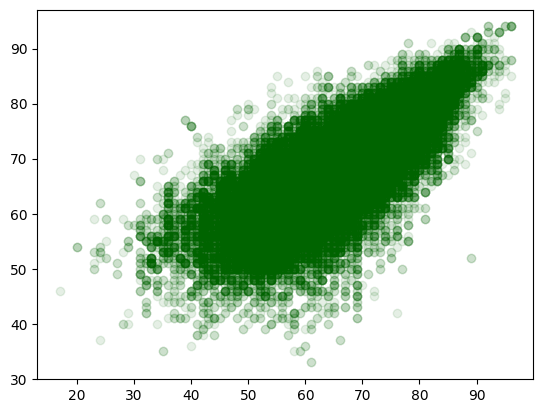

In [108]:
plt.scatter(x['reactions'],y,color='darkgreen',label='datos', alpha=.1)

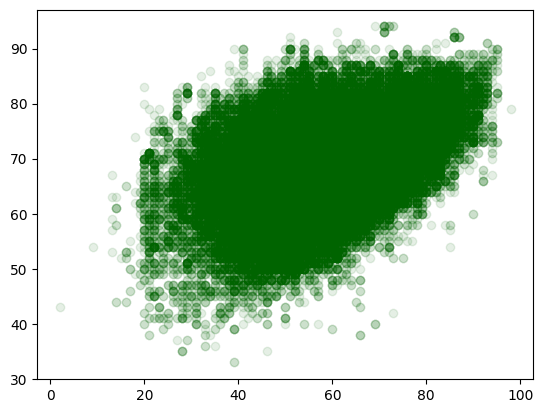

In [109]:
plt.scatter(x['heading_accuracy'],y,color='darkgreen',label='datos', alpha=.1)

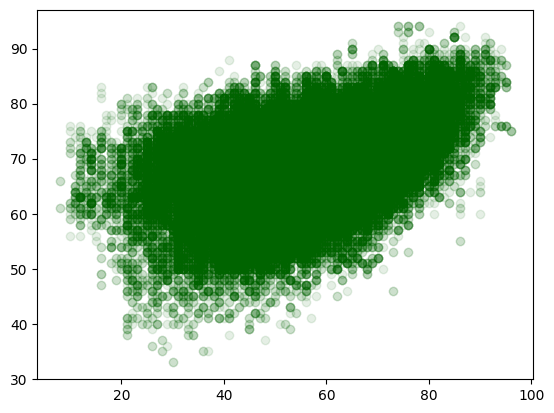

In [110]:
plt.scatter(x['penalties'],y,color='darkgreen',label='datos', alpha=.1)

### Separacion de los datos en Training y Test Datasets

In [111]:
#test_size: porcentaje de datos que se van a usar para testear el modelo
#random_state: semilla para la generación de números aleatorios, para que los resultados sean reproducibles
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.33,random_state=324)

### Utilizar un escalado estandar 
Para que los datos de cada caracteristica se acoplen a un rango y se evieten los esgos de un feature convalores muy altos que pueden influir de mas en el taget

In [112]:
#Escalado de los datos para evitar sesgos en el modelo
scale=preprocessing.StandardScaler()

### Entrenar con los datos escalados

In [113]:
scale.fit(x_train)

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [114]:
#x_train=scale.transform(x_train)
x_train = pd.DataFrame(scale.transform(x_train), columns=features)

In [115]:
#imprimir los nuevos valores minimo y maximo de las features de entrenamiento 
x_train.min(), x_train.max()

(potential            -5.281926
 crossing             -3.630796
 finishing            -2.676177
 heading_accuracy     -4.189264
 short_passing        -5.063503
 volleys              -2.882326
 dribbling            -4.149384
 curve                -2.992399
 free_kick_accuracy   -2.942741
 acceleration         -4.317374
 reactions            -5.576618
 balance              -3.918966
 shot_power           -4.454812
 jumping              -4.348380
 stamina              -4.627290
 strength             -4.621190
 long_shots           -3.225792
 aggression           -3.993798
 interceptions        -2.406312
 positioning          -3.277882
 vision               -3.884472
 penalties            -3.634841
 marking              -2.239415
 standing_tackle      -2.444850
 dtype: float64,
 potential             3.581382
 crossing              2.640891
 finishing             2.586735
 heading_accuracy      3.036112
 short_passing         3.152836
 volleys               2.532033
 dribbling             

### Creamos un aintancia del modelo de regresion lineal de Scikit Learn

In [116]:
regresor=LinearRegression()

### Ajustando el modelo a los datos de entrenamiento

In [117]:
regresor.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Realizar una prediccion usando eel conjunto de datos de prueba(test set)

In [118]:
#Escalar los valores de prueba para que coincidan con los de entrenamiento
#x_test=scale.transform(x_test)
x_test = pd.DataFrame(scale.transform(x_test), columns=features)


In [119]:
# hacer una prediccion del valor de salida , pasandole los valores de prueba
y_prediccion=regresor.predict(x_test)

In [120]:
#Obtener la diferencia entre los valores de salida predichos y los valores reales
y_result=y_prediccion-y_test
y_result

22033     3.149234
62484     0.503681
99345     0.636742
28085     0.821320
92973    -8.075141
            ...   
163910   -1.186424
166651   -3.545258
26398    -1.265349
176846    4.328323
136352   -2.130800
Name: overall_rating, Length: 54603, dtype: float64

### Calcular la raiz cuadrada del Error Cuadratico Medio

In [121]:
#Ingresamos el valor real del target que es y_test y el valor predicho por el modelo que es y_pred, para obtener el error cuadrático medio
RMSE=sqrt(mean_squared_error(y_true=y_test,y_pred=y_prediccion))
print(RMSE)


2.759502377463964


### Mostrar la prediccion que obtuvo el modelo al predecir los valores de prueba

In [122]:
regresor.score(x_test,y_test)

0.8431650535209274

### Mostrar cual es el valor de cada w que se aplico a cada feature (w*x) para que al sumar topdos los productos nos de el puntaje de cada jugador

In [73]:
regresor.coef_

array([ 2.48175418,  0.37435166,  0.2155902 ,  1.14537904,  0.72579619,
        0.08835762, -0.2396529 ,  0.20341906,  0.23070925,  0.08573083,
        2.03147644,  0.08063536,  0.11593773, -0.09744622,  1.92780373,
        0.10753058,  0.27833167,  0.16277628, -0.08089224,  0.73874625,
       -0.25048481,  0.33897633,  0.22293067, -0.18511046, -0.01892236,
        0.21517621,  0.70526674,  0.07880386, -0.61339243,  2.72376613,
        0.51832172, -0.70907673,  0.91420565,  0.43578429])

In [74]:
regresor.intercept_

np.float64(68.6350703840711)